# SMOTE

### 1) Import required Libraries

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### 2) Load the dataset

In [2]:
smote_df=pd.read_csv("Dataset/dataset_smote.csv")

In [3]:
X_smote=smote_df.drop(columns=['insider'])
y_smote=smote_df['insider']

In [4]:
features = list(X_smote.columns)

### 3) Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_smote,
    y_smote,
    test_size=0.2,
    stratify=y_smote
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1107747, 829)
Test shape: (276937, 829)


### 4) Standardization

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 5) PCA

In [7]:
from sklearn.decomposition import PCA

pca_nb = PCA(n_components=5)

X_train_pca_nb = pca_nb.fit_transform(X_train)
X_test_pca_nb = pca_nb.transform(X_test)

pca_lr = PCA(n_components=1)
X_train_pca_lr = pca_lr.fit_transform(X_train)
X_test_pca_lr = pca_lr.transform(X_test)

pca_rf = PCA(n_components=10)
X_train_pca_rf = pca_rf.fit_transform(X_train)
X_test_pca_rf = pca_rf.transform(X_test)

pca_dt = PCA(n_components=50)
X_train_pca_dt = pca_dt.fit_transform(X_train)
X_test_pca_dt = pca_dt.transform(X_test)

pca_adb = PCA(n_components=50, random_state=30)

X_train_pca_adb = pca_adb.fit_transform(X_train)
X_test_pca_adb = pca_adb.transform(X_test)


### 6) ML Models

In [8]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C=0.01, 
    max_iter=5000, 
    class_weight={0: 1.26, 1: 1.08},
    solver='lbfgs',
    random_state=42
)

lr.fit(X_train_pca_lr, y_train)
y_pred_lr = lr.predict(X_test_pca_lr)

print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.0%}")
print(classification_report(y_test, y_pred_lr, target_names=['NO', 'YES']))

Logistic Regression
Accuracy: 58%
              precision    recall  f1-score   support

          NO       0.56      0.75      0.64    138469
         YES       0.62      0.42      0.50    138468

    accuracy                           0.58    276937
   macro avg       0.59      0.58      0.57    276937
weighted avg       0.59      0.58      0.57    276937



In [11]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=16,
    min_samples_leaf=10, 
    random_state=30
)

dt.fit(X_train_pca_dt, y_train)
probs = dt.predict_proba(X_test_pca_dt)[:, 1]

threshold = 0.85
y_pred_dt = (probs > threshold).astype(int)

print("Decision Tree")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.0%}")
print(classification_report(y_test, y_pred_dt, target_names=['NO', 'YES']))

Decision Tree
Accuracy: 98%
              precision    recall  f1-score   support

          NO       0.99      0.97      0.98    138469
         YES       0.97      0.99      0.98    138468

    accuracy                           0.98    276937
   macro avg       0.98      0.98      0.98    276937
weighted avg       0.98      0.98      0.98    276937



In [12]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15, 
    min_samples_leaf=5,
    random_state=30,
    n_jobs=-1
)

rf.fit(X_train_pca_rf, y_train)
probs = rf.predict_proba(X_test_pca_rf)[:, 1]

threshold = 0.71
y_pred_rf = (probs > threshold).astype(int)

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.1%}")
print(classification_report(y_test, y_pred_rf, target_names=['NO', 'YES'], digits=3))

Random Forest
Accuracy: 98.3%
              precision    recall  f1-score   support

          NO      0.984     0.981     0.982    138469
         YES      0.981     0.984     0.983    138468

    accuracy                          0.983    276937
   macro avg      0.983     0.983     0.983    276937
weighted avg      0.983     0.983     0.983    276937



In [13]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils import resample

X_train_small, y_train_small = resample(
    X_train_pca_adb,
    y_train,
    n_samples=75000,
    stratify=y_train,
    random_state=30
)

base_tree = DecisionTreeClassifier(
    max_depth=5,          
    min_samples_leaf=2,   
    random_state=30
)

ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=80,      
    learning_rate=0.5,   
    random_state=30
)

ada.fit(X_train_small, y_train_small)

y_pred_ada = ada.predict(X_test_pca_adb)

print("AdaBoost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.0%}")
print(classification_report(y_test, y_pred_ada, target_names=['NO', 'YES']))

AdaBoost
Accuracy: 98%
              precision    recall  f1-score   support

          NO       0.99      0.97      0.98    138469
         YES       0.97      0.99      0.98    138468

    accuracy                           0.98    276937
   macro avg       0.98      0.98      0.98    276937
weighted avg       0.98      0.98      0.98    276937



In [14]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB(priors=[0.502, 0.498])

nb.fit(X_train_pca_nb, y_train)
y_pred_nb = nb.predict(X_test_pca_nb)

print("Naive Bayes")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.0%}")
print(classification_report(y_test, y_pred_nb))

Naive Bayes
Accuracy: 74%
              precision    recall  f1-score   support

           0       0.69      0.88      0.77    138469
           1       0.83      0.61      0.70    138468

    accuracy                           0.74    276937
   macro avg       0.76      0.74      0.74    276937
weighted avg       0.76      0.74      0.74    276937



In [15]:
import joblib

joblib.dump({
    "scaler": scaler,
    "pca": pca_dt,
    "model": dt,
    "features": features
}, "dt_smote.pkl")

joblib.dump({
    "scaler": scaler,
    "pca": pca_rf,
    "model": rf,
    "features": features
}, "rf_smote.pkl")

joblib.dump({
    "scaler": scaler,
    "pca": pca_adb,
    "model": ada,
    "features": features
}, "ada_smote.pkl")

['ada_smote.pkl']

### 7) Ensemble Learning

In [14]:
pca_ens = PCA(n_components = 50)

In [15]:
X_train_ens, y_train_ens = resample(
    X_train,
    y_train,
    n_samples=75000,
    stratify=y_train,
    random_state=30
)

print("Ensemble Training Shape:", X_train_ens.shape)

Ensemble Training Shape: (75000, 829)


In [16]:
X_train_ens = pca_ens.fit_transform(X_train_ens)
X_test_ens = pca_ens.transform(X_test)

print(X_train_ens.shape)

(75000, 50)


In [17]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('adb', ada)
    ],
    voting='soft',
    weights=[1, 2, 1], 
    n_jobs=-1
)

voting.fit(X_train_ens, y_train_ens)

y_pred_vote = voting.predict(X_test_ens)

print("\nVoting Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_vote):.1%}")
print(classification_report(y_test, y_pred_vote, target_names=['NO','YES']))

/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version 


Voting Classifier
Accuracy: 98.0%
              precision    recall  f1-score   support

          NO       0.99      0.97      0.98    138469
         YES       0.97      0.99      0.98    138468

    accuracy                           0.98    276937
   macro avg       0.98      0.98      0.98    276937
weighted avg       0.98      0.98      0.98    276937



In [31]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('adb', ada)
    ],
    final_estimator=LogisticRegression(C=20, max_iter=10000, class_weight='balanced'),
    passthrough=True,
    cv=10,
    n_jobs=-1
)

stack.fit(X_train_ens, y_train_ens)

y_pred_stack = stack.predict(X_test_ens)

print("\nStacking Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack):.1%}")
print(classification_report(y_test, y_pred_stack, target_names=['NO','YES']))

/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version 


Stacking Classifier
Accuracy: 99.0%
              precision    recall  f1-score   support

          NO       0.99      0.99      0.99    138469
         YES       0.99      0.99      0.99    138468

    accuracy                           0.99    276937
   macro avg       0.99      0.99      0.99    276937
weighted avg       0.99      0.99      0.99    276937



In [27]:
import joblib

joblib.dump({
    "scaler": scaler,
    "pca": pca_ens,
    "model": voting,
    "features": features
}, "smote_voting_model_ens.pkl")

['smote_voting_model_ens.pkl']

In [32]:
joblib.dump({
    "scaler": scaler,
    "pca": pca_ens,
    "model": stack,
    "features": features
}, "smote_stacking_model_ens.pkl")

['smote_stacking_model_ens.pkl']

### 8) Visualization

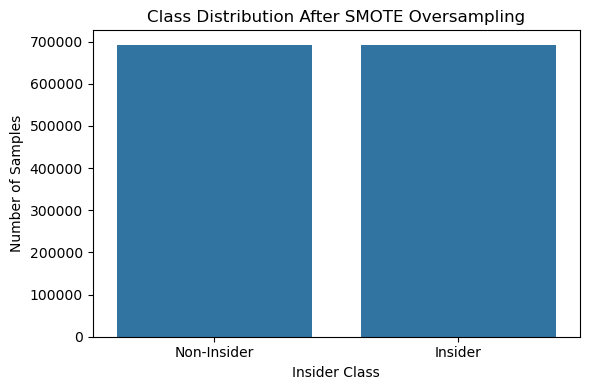

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='insider', data=smote_df)

plt.title("Class Distribution After SMOTE Oversampling")
plt.xlabel("Insider Class")
plt.ylabel("Number of Samples")

plt.xticks([0,1], ['Non-Insider','Insider'])

plt.tight_layout()
plt.savefig("class_dist_smote.png", dpi=300, bbox_inches='tight')
plt.show()